In [1]:
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
datasets = ["data/XLB.txt","data/XLC.txt","data/XLE.txt","data/XLF.txt","data/XLI.txt","data/XLK.txt","data/XLP.txt","data/XLRE.txt","data/XLU.txt","data/XLY.txt"]
filename = datasets[9]
cols = ['Date', 'Time', 'Open', 'High', 'Low', 'Close', 'Volume']
df = pd.read_csv(filename, names=cols)
#problem 1,7 datasets XLC XLRE
# Combine Date and Time into a single index
df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df.set_index('Timestamp', inplace=True)
df.head()

,Date,Time,Open,High,Low,Close,Volume
Timestamp,,,,,,,
1998-12-22 10:49:00,12/22/1998,10:49,18.8429,18.8429,18.8429,18.8429,672
1998-12-22 11:15:00,12/22/1998,11:15,18.9127,18.9127,18.9127,18.9127,134
1998-12-22 11:58:00,12/22/1998,11:58,18.8894,18.8894,18.8894,18.8894,2015
1998-12-22 12:05:00,12/22/1998,12:05,18.9127,18.9127,18.9127,18.9127,134
1998-12-22 12:14:00,12/22/1998,12:14,18.8894,18.8894,18.8894,18.8894,403


In [3]:
daily_results = []
start_date = datetime(2009, 1, 1)
end_date = datetime(2024,12,31)
df = df[(df.index >= start_date) & (df.index <= end_date)]
df

,Date,Time,Open,High,Low,Close,Volume
Timestamp,,,,,,,
2009-01-02 09:06:00,01/02/2009,09:06,17.6183,17.6183,17.6183,17.6183,49217
2009-01-02 09:30:00,01/02/2009,09:30,17.6592,17.6755,17.5448,17.6755,47994
2009-01-02 09:31:00,01/02/2009,09:31,17.6183,17.6265,17.6101,17.6101,6508
2009-01-02 09:32:00,01/02/2009,09:32,17.6101,17.6142,17.6020,17.6020,4022
2009-01-02 09:33:00,01/02/2009,09:33,17.5611,17.5775,17.5530,17.5611,1592
...,...,...,...,...,...,...,...
2024-12-30 16:15:00,12/30/2024,16:15,225.8200,225.8200,225.8200,225.8200,748
2024-12-30 16:17:00,12/30/2024,16:17,226.1100,226.1100,226.1100,226.1100,700
2024-12-30 16:21:00,12/30/2024,16:21,226.0700,226.0800,225.9800,226.0800,1159


In [4]:
counts = []

for date, day_data in df.groupby(df.index.date):
    num_observations = len(day_data) 
    counts.append(num_observations)

counts = np.array(counts)
print(np.mean(counts))

395.1970186335404


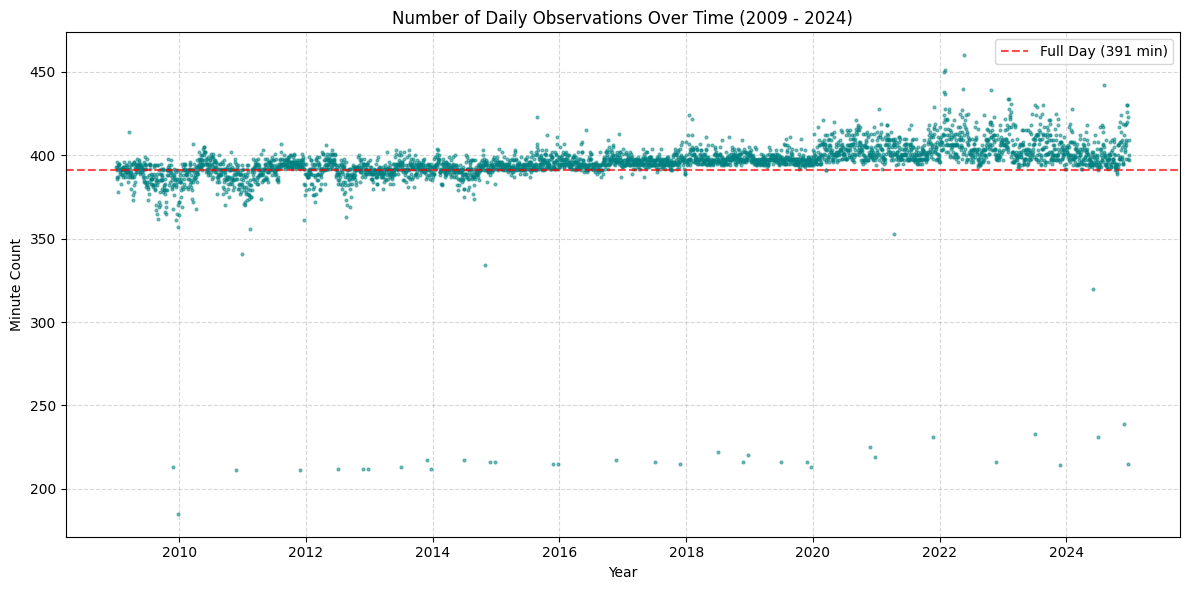

In [5]:
daily_counts = df.groupby(df.index.date).size()

# 2. Plotting the distribution over time
plt.figure(figsize=(12, 6))
plt.plot(daily_counts.index, daily_counts.values, marker='o', linestyle='', markersize=2, alpha=0.5, color='teal')

# Add a horizontal line for a full trading day (391 minutes)
plt.axhline(y=391, color='red', linestyle='--', alpha=0.7, label='Full Day (391 min)')

# Formatting
plt.title('Number of Daily Observations Over Time (2009 - 2024)')
plt.xlabel('Year')
plt.ylabel('Minute Count')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

# Ensure the x-axis looks clean with dates
plt.tight_layout()
plt.savefig('observations_over_time.png')

In [6]:
less_then = 0
threshold =0
for c in daily_counts:
    if c <threshold:
        less_then+=1
print(len(daily_counts))
less_then


4025


0

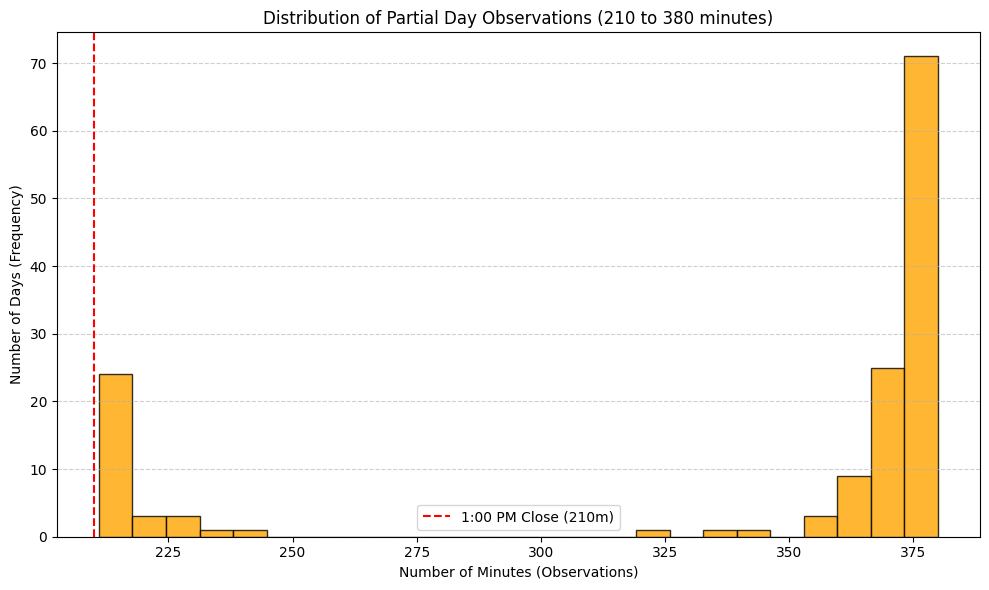

In [7]:
partial_days = daily_counts[(daily_counts >= 210) & (daily_counts <= 380)]

# 3. Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(partial_days, bins=25, color='orange', edgecolor='black', alpha=0.8)

# Formatting
plt.title('Distribution of Partial Day Observations (210 to 380 minutes)')
plt.xlabel('Number of Minutes (Observations)')
plt.ylabel('Number of Days (Frequency)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Highlight the 1:00 PM early close (210 mins)
plt.axvline(210, color='red', linestyle='dashed', label='1:00 PM Close (210m)')
plt.legend()

plt.tight_layout()
plt.savefig('filtered_daily_counts.png')

In [8]:
threshold = 0
good_days = daily_counts[daily_counts >= threshold].index
dates_series = pd.Series(df.index.date, index=df.index)

In [9]:
df_filtered = df[dates_series.isin(good_days)].copy()

# Now safely add the new column
df_filtered['minute_of_day'] = (df_filtered.index.hour - 9) * 60 + (df_filtered.index.minute - 30)

# Keep only valid minutes
df_filtered = df_filtered[(df_filtered['minute_of_day'] >= 0) & (df_filtered['minute_of_day'] < 390)]
df_filtered

,Date,Time,Open,High,Low,Close,Volume,minute_of_day
Timestamp,,,,,,,,
2009-01-02 09:30:00,01/02/2009,09:30,17.6592,17.6755,17.5448,17.6755,47994,0
2009-01-02 09:31:00,01/02/2009,09:31,17.6183,17.6265,17.6101,17.6101,6508,1
2009-01-02 09:32:00,01/02/2009,09:32,17.6101,17.6142,17.6020,17.6020,4022,2
2009-01-02 09:33:00,01/02/2009,09:33,17.5611,17.5775,17.5530,17.5611,1592,3
2009-01-02 09:34:00,01/02/2009,09:34,17.5693,17.5856,17.5693,17.5775,10907,4
...,...,...,...,...,...,...,...,...
2024-12-30 15:55:00,12/30/2024,15:55,226.6700,226.7000,226.5400,226.6600,22938,385
2024-12-30 15:56:00,12/30/2024,15:56,226.6500,226.6700,226.3600,226.3750,22689,386
2024-12-30 15:57:00,12/30/2024,15:57,226.3700,226.4200,226.3450,226.3601,9293,387


In [10]:
hist = df_filtered.groupby('minute_of_day').size()
hist_fraction = hist / len(good_days)

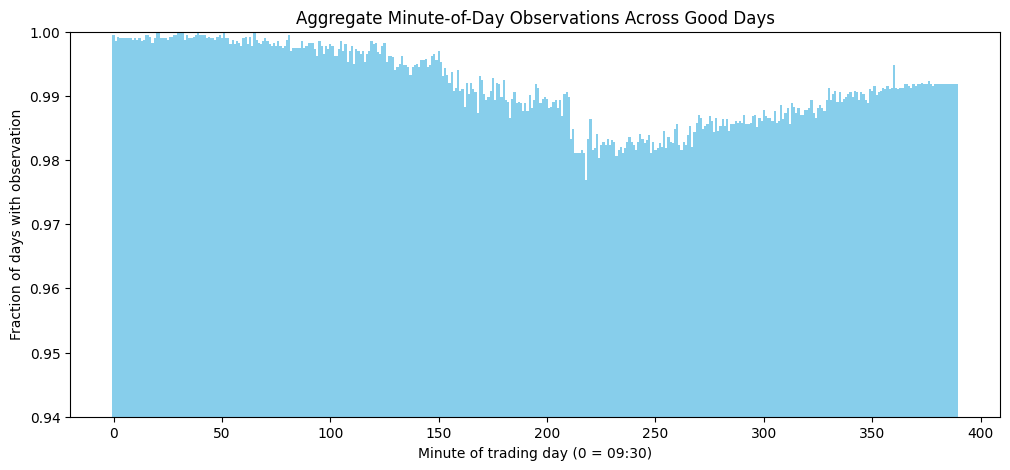

In [11]:
plt.figure(figsize=(12,5))
plt.bar(hist_fraction.index, hist_fraction.values, width=1.0, color='skyblue')
plt.xlabel('Minute of trading day (0 = 09:30)')
plt.ylabel('Fraction of days with observation')
plt.title('Aggregate Minute-of-Day Observations Across Good Days')

plt.ylim(0.94, 1.0)
plt.show()
#0,1,5, 6, 7, 9

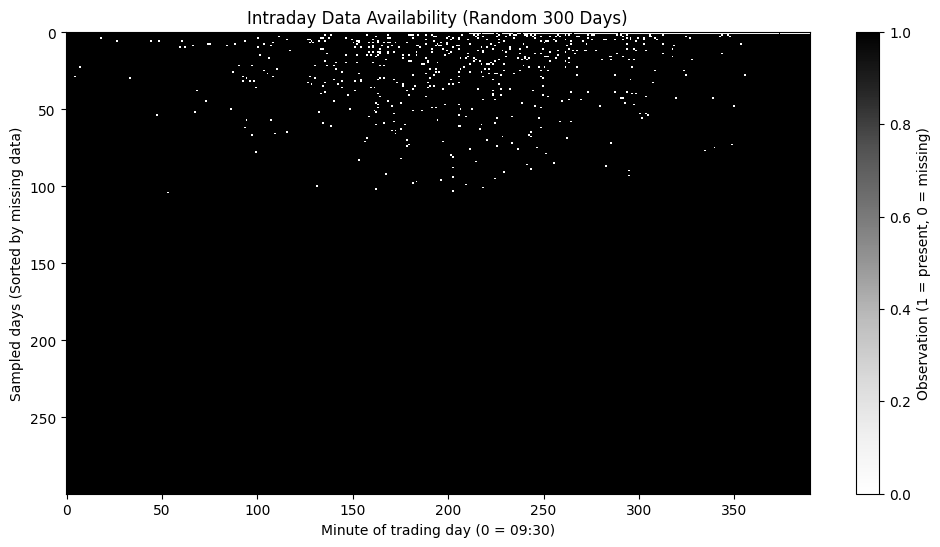

In [12]:
# 1. Setup
unique_days = np.unique(df_filtered.index.date)
n_days = len(unique_days)
n_minutes = 390  # Change to 391 if you have data exactly at 16:00

day_to_idx = {day: i for i, day in enumerate(unique_days)}

# 2. Initialize binary matrix
matrix = np.zeros((n_days, n_minutes))

# 3. Fill matrix safely
for ts in df_filtered.itertuples():
    day = ts.Index.date()
    # Calculate minute offset directly from the DatetimeIndex
    minute = int((ts.Index.hour * 60 + ts.Index.minute) - 570) 
    
    if 0 <= minute < n_minutes:
        matrix[day_to_idx[day], minute] = 1

# 4. Random sample 300 days (if more than 300)
np.random.seed(100)
if n_days > 300:
    sample_idx = np.random.choice(n_days, 300, replace=False)
else:
    sample_idx = np.arange(n_days)

sample_matrix = matrix[sample_idx, :]

# 5. Sort rows by total observations
row_sums = sample_matrix.sum(axis=1)
sorted_idx = np.argsort(row_sums)
sample_matrix = sample_matrix[sorted_idx, :]

# 6. Plot heatmap
plt.figure(figsize=(12, 6))
plt.imshow(sample_matrix, aspect='auto', cmap='Greys', interpolation='none')
plt.xlabel('Minute of trading day (0 = 09:30)')
plt.ylabel('Sampled days (Sorted by missing data)')
plt.title('Intraday Data Availability (Random 300 Days)')
plt.colorbar(label='Observation (1 = present, 0 = missing)')
plt.show()

In [13]:
datasets = [
    "data/XLB.txt","data/XLE.txt","data/XLF.txt",
    "data/XLI.txt","data/XLK.txt","data/XLP.txt",
    "data/XLU.txt","data/XLY.txt"
]

cols = ['Date', 'Time', 'Open', 'High', 'Low', 'Close', 'Volume']
threshold = 300
start_date = datetime(2009, 1, 1)
end_date = datetime(2024,12,31)

good_days_list = []
dataframes = []
daily_counts_list = []
for filename in datasets:
    df = pd.read_csv(filename, names=cols)
    df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
    df.set_index('Timestamp', inplace=True)
    df = df[(df.index >= start_date) & (df.index <= end_date)]
    dataframes.append(df)

    daily_counts = df.groupby(df.index.date).size()
    daily_counts_list.append(daily_counts)
    
    daily_counts = df.groupby(df.index.date).size()
    good_days = set(daily_counts[daily_counts >= threshold].index)
    good_days_list.append(good_days)

common_good_days = set.intersection(*good_days_list)
print(f"nr common good days: {len(common_good_days)}")




nr common good days: 3992


In [17]:
import os

# --- diagnose dropped dates ---
asset_names = [os.path.basename(f).replace('.txt', '') for f in datasets]

# Union of all dates that appeared in any asset's data within the date range
all_dates = set().union(*[set(gd) for gd in good_days_list]) | \
            set().union(*[set(dc.index) for dc in daily_counts_list])

dropped_dates = all_dates - common_good_days

print(f"\nDates dropped: {len(dropped_dates)} "
      f"(out of {len(all_dates)} total dates seen)")

# For each dropped date, find which assets failed the threshold
drop_details = []
for d in sorted(dropped_dates):
    failing_assets = [
        asset_names[i] for i, good_days in enumerate(good_days_list)
        if d not in good_days
    ]
    n_passing = len(datasets) - len(failing_assets)
    drop_details.append({
        'date': d,
        'n_assets_passing': n_passing,
        'failing_assets': ','.join(failing_assets) if failing_assets else '(none)'
    })

# Summary
n_completely_bad = sum(1 for r in drop_details if r['n_assets_passing'] == 0)
n_partial = sum(1 for r in drop_details
                if 0 < r['n_assets_passing'] < len(datasets))
print(f"  No asset met threshold:      {n_completely_bad}")
print(f"  Some but not all assets met: {n_partial}")

# Print first 20 to console
print(f"\nFirst {min(33, len(drop_details))} dropped dates:")
for r in drop_details[:33]:
    print(f"  {r['date']}  "
          f"{r['n_assets_passing']}/{len(datasets)} assets passed  "
          f"failing: {r['failing_assets']}")

# Save full list for inspection
pd.DataFrame(drop_details).to_csv("data/dropped_dates.csv", index=False)
print(f"\nFull list saved to data/dropped_dates.csv")


Dates dropped: 33 (out of 4025 total dates seen)
  No asset met threshold:      23
  Some but not all assets met: 10

First 33 dropped dates:
  2009-11-27  1/8 assets passed  failing: XLB,XLE,XLI,XLK,XLP,XLU,XLY
  2009-12-24  0/8 assets passed  failing: XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLY
  2010-11-26  0/8 assets passed  failing: XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLY
  2011-11-25  0/8 assets passed  failing: XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLY
  2012-07-03  0/8 assets passed  failing: XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLY
  2012-11-23  0/8 assets passed  failing: XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLY
  2012-12-24  0/8 assets passed  failing: XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLY
  2013-07-03  0/8 assets passed  failing: XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLY
  2013-11-29  0/8 assets passed  failing: XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLY
  2013-12-24  0/8 assets passed  failing: XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLY
  2014-07-03  0/8 assets passed  failing: XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLY
  2014-11-28  1/8 assets passed  failing: XLB,X

In [14]:
sorted_dates = sorted(common_good_days)
output_dir = "data/"
os.makedirs(output_dir, exist_ok=True)

# Plain text file: one date per line in YYYY-MM-DD format
with open(os.path.join(output_dir, "final_dates.txt"), "w") as f:
    for d in sorted_dates:
        f.write(f"{d.isoformat()}\n")

# Or as a pandas Series for easier downstream loading (CSV with one column)
pd.Series(sorted_dates, name="date").to_csv(
    os.path.join(output_dir, "final_dates.csv"),
    index=False
)

print(f"Saved {len(sorted_dates)} dates to {output_dir}final_dates.txt and "
      f"{output_dir}final_dates.csv")
print(f"First date: {sorted_dates[0]}")
print(f"Last date:  {sorted_dates[-1]}")

Saved 3992 dates to data/final_dates.txt and data/final_dates.csv
First date: 2009-01-02
Last date:  2024-12-30


In [16]:
aligned = pd.DataFrame({
    i: dc for i, dc in enumerate(daily_counts_list)
}).fillna(0)

aligned.index = sorted(set.intersection(*[set(dc.index) for dc in daily_counts_list]))

last_1000 = aligned.index[-9000:]

bad_calendar_days_last_1000 = (aligned.loc[last_1000] < threshold).any(axis=1).sum()

print(bad_calendar_days_last_1000)

33


In [17]:
filtered_dfs = []
for df in dataframes:
    dates_series = pd.Series(df.index.date, index=df.index)
    df_filtered = df[dates_series.isin(common_good_days)].copy()
    filtered_dfs.append(df_filtered)

In [18]:
filtered_dfs[0].head(30)

,Date,Time,Open,High,Low,Close,Volume
Timestamp,,,,,,,
2009-01-02 08:13:00,01/02/2009,08:13,16.1147,16.1147,16.1147,16.1147,287306
2009-01-02 08:49:00,01/02/2009,08:49,15.9801,15.9801,15.9801,15.9801,564
2009-01-02 08:59:00,01/02/2009,08:59,15.9446,15.9446,15.9446,15.9446,563
2009-01-02 09:06:00,01/02/2009,09:06,16.1147,16.1147,16.1147,16.1147,39935
2009-01-02 09:10:00,01/02/2009,09:10,16.1147,16.1147,16.1147,16.1147,100190
2009-01-02 09:30:00,01/02/2009,09:30,16.2281,16.2352,16.1572,16.1927,20579
2009-01-02 09:31:00,01/02/2009,09:31,16.1785,16.1785,16.1785,16.1785,141
2009-01-02 09:32:00,01/02/2009,09:32,16.2068,16.2210,16.2068,16.2210,423
2009-01-02 09:33:00,01/02/2009,09:33,16.2068,16.2210,16.1998,16.2139,13818


In [19]:
def day_align(day, date):
    one_min_grid = pd.date_range(start=f"{date} 09:30", end=f"{date} 16:00", freq="1min").time
    
    df_al =  pd.DataFrame(columns=["Close"])
    pre_930 = day[day.index.time < pd.to_datetime("09:30").time()]
    if not pre_930.empty:
        last_pre_930 = pre_930["Close"].iloc[-1]
        synthetic_time = pd.Timestamp(f"{date} 09:29")
        df_al.loc[synthetic_time] = [last_pre_930]
    i = 0
    last_obs = day.iloc[0]["Close"]
    for g in one_min_grid:
        while i < len(day) and g > day.index[i].time():
            i += 1
        if i < len(day):
            value = day.iloc[i]["Close"]
            last_obs = value
        else:
            value = last_obs
        time_str = f"{date} {g.strftime('%H:%M:%S')}"
        df_al.loc[pd.Timestamp(time_str)] = [value]
    special_time = pd.Timestamp(f"{date} 20:00")
    df_al.loc[special_time] = [day["Close"].iloc[-1]]
    #print(df_al)
    return df_al

In [20]:
def day_align2(day, date):
    one_min_grid = pd.date_range(start=f"{date} 09:30", end=f"{date} 16:00", freq="1min").time
    
    df_al = pd.DataFrame(columns=["Close"])
    i = 0
    last_obs = day.iloc[0]["Close"]
    
    for g in one_min_grid:
        while i < len(day) and g > day.index[i].time():
            i += 1
        if i < len(day):
            value = day.iloc[i]["Close"]
            last_obs = value
        else:
            value = last_obs
        time_str = f"{date} {g.strftime('%H:%M:%S')}"
        df_al.loc[pd.Timestamp(time_str)] = [value]
    
    return df_al

In [ ]:
aligned_datasets = []
i=0
for df_filtered in filtered_dfs:
    aligned_days = []
    print(f"Processing {datasets[i]}-th dataset")
    for date, day_data in df_filtered.groupby(df_filtered.index.date):
        aligned_day = day_align2(day_data, date)
        aligned_days.append(aligned_day)
    df_aligned = pd.concat(aligned_days)
    df_aligned.sort_index(inplace=True)
    aligned_datasets.append(df_aligned)
    print(f"Dataset {datasets[i]} processed!")
    i+=1


Processing data/XLB.txt-th dataset


In [ ]:
for i in aligned_datasets:
    print(i.count())

In [ ]:
output_dir = "data/aligned"
os.makedirs(output_dir, exist_ok=True)

for i, df_aligned in enumerate(aligned_datasets):
    filename = datasets[i].split('/')[-1].replace('.txt', '_c_aligned.txt')
    path = os.path.join(output_dir, filename)
    
    df_aligned.to_csv(path, sep='\t')  # tab-separated, adjust sep if you want
    print(f"Saved aligned dataset to {path}")